# 02 · Theory, losses, and learning the loss

Three results, each a formula checked against simulation:

1. **The ceiling.** An oracle that knows both laws errs with probability
   $P_\mathrm{err} = Q\big(\sqrt{n\rho}/2\big)$ per window, with
   $\rho = \mathbb{E}[(f_1-f_0)^2]/\sigma^2$ (V1-V7, `lrdsr.theory.verification`).
2. **What a loss costs (V8).** A decision made with loss $\rho(\cdot)$ and
   influence $\psi = \rho'$ errs with
   $Q\big(\sqrt{n\rho\,\eta}/2\big)$, where
   $\eta = \mathrm{Var}(e)\,(\mathbb{E}\psi')^2 / (s^2\,\mathbb{E}\psi^2)$ is the
   loss's efficiency under the noise (`lrdsr.theory.losses`). Squared loss has
   $\eta = 1$ under *every* noise; the likelihood-ratio loss reaches the
   maximum, $\mathrm{Var}(e)\,I(p)$.
3. **How fast a switch is seen (V9).** CUSUM detects a change of law after
   $\approx h/\mathrm{KL} = 2h/\rho$ samples and false-alarms at most every
   $\approx e^h$ (`lrdsr.theory.sequential`).

In [1]:
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from lrdsr import viz
viz.style()
pd.set_option("display.precision", 4)
RES = ROOT / "results"

## 1 · The ceiling, live

Simulate the oracle on the polynomial pair $x^2 \pm x$ (gap $2x$) at many
$n\rho$ and lay the result on $Q(\sqrt{n\rho}/2)$. The small upward bias at
large $n\rho$ is the Jensen step from the realised design to the population
form, which V2 prices exactly.

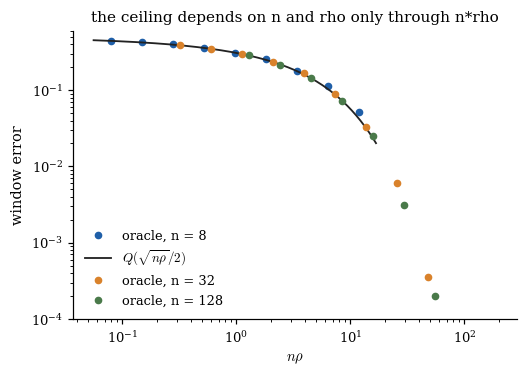

In [2]:
rng = np.random.default_rng(11)
rows = []
for n in (8, 32, 128):
    for rho in np.geomspace(0.01, 1.5, 9):
        x = rng.uniform(-2, 2, (20000, n))
        sigma = np.sqrt((16 / 3) / rho)
        y = x**2 + x + rng.normal(0, sigma, x.shape)                 # truth: f0
        err = np.mean(np.sum((y - (x**2 - x))**2, 1) < np.sum((y - (x**2 + x))**2, 1))
        rows.append((n, rho, n * rho, err))
sim = pd.DataFrame(rows, columns=["n", "rho", "n_rho", "error"])
ax = None
for i, (n, g) in enumerate(sim.groupby("n")):
    ax = viz.plot_error_curve(g.n_rho, g.error, ax=ax, label=f"oracle, n = {n}",
                              theory=(i == 0), color=viz.PALETTE[i])
ax.set_ylim(1e-4, 0.6); ax.set_title("the ceiling depends on n and rho only through n*rho");

## 2 · The loss family

Each loss is a penalty on the scaled residual; its influence $\psi$ says how
hard one sample can pull. Squared loss has unbounded influence, Huber caps it,
Cauchy / Student-t / Tukey let it fall back towards zero (*redescending*).

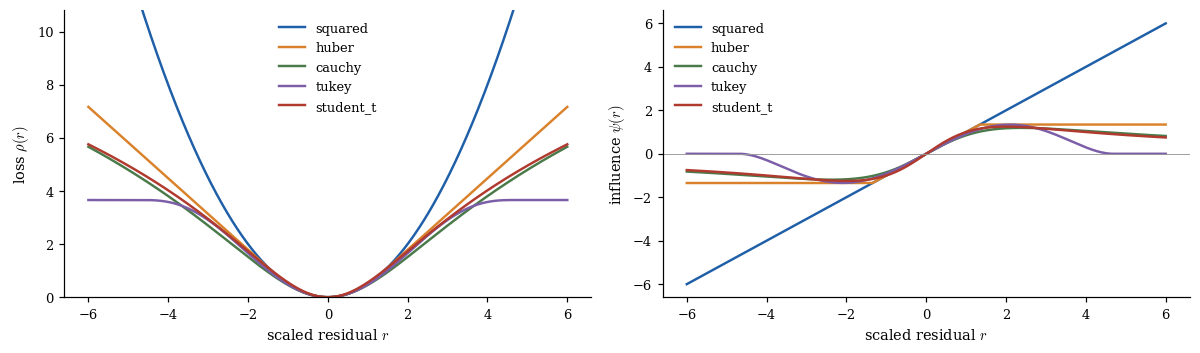

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
viz.plot_losses(ax=ax[0]); viz.plot_losses(ax=ax[1], influence=True)
fig.tight_layout()

## 3 · Efficiency: which loss, under which noise

$\eta$ by quadrature for every loss and noise law. Read each row against its
`lrt` column, the best any loss can do.

In [4]:
from lrdsr.theory.losses import LOSS_GRID, efficiency, lrt_efficiency, noise_families

fams = noise_families()
eta = pd.DataFrame({name: {**{loss: efficiency(loss, nz, **p) for loss, p in LOSS_GRID.items()},
                           "lrt": lrt_efficiency(nz)} for name, nz in fams.items()}).T
eta.round(3)

,squared,absolute,huber,cauchy,tukey,student_t,lrt
gaussian,1.0,0.637,0.950,0.950,0.950,0.926,1.000
laplace,1.0,2.000,1.395,1.454,1.390,1.512,2.000
student_t3,1.0,1.621,1.890,1.933,1.914,1.974,2.000
contaminated_10,1.0,5.746,7.525,8.298,8.902,8.396,9.019
contaminated_20,1.0,8.904,9.842,11.718,13.629,12.466,14.331


Under Gaussian noise nothing beats squared loss, and the robust losses give up
4-5%. Under 10% contamination the squared loss is **nine times** less
efficient than the likelihood ratio: it needs nine times as many samples a
window for the same error. The table is the whole argument for choosing the
loss by the noise, and the next cell checks it against simulation.

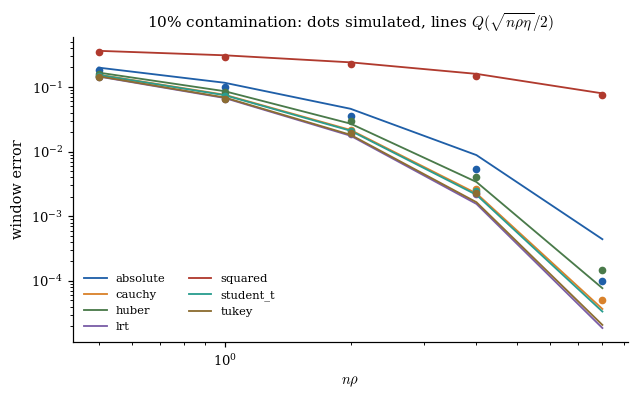

In [5]:
from lrdsr.theory.losses import simulate_error

nz = fams["contaminated_10"]
rows = []
for n_rho in (0.5, 1, 2, 4, 8):
    out = simulate_error(nz, n=64, rho=n_rho / 64, seed=11, n_windows=20000)
    for loss, (sim_err, pred, e) in out.items():
        rows.append({"loss": loss, "n_rho": n_rho, "simulated": sim_err, "predicted": pred})
df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for i, (loss, g) in enumerate(df.groupby("loss")):
    ax.plot(g.n_rho, g.simulated, "o", color=viz.PALETTE[i], ms=4)
    ax.plot(g.n_rho, g.predicted, "-", color=viz.PALETTE[i], lw=1.2, label=loss)
ax.set(xscale="log", yscale="log", xlabel=r"$n\rho$", ylabel="window error",
       title="10% contamination: dots simulated, lines $Q(\\sqrt{n\\rho\\eta}/2)$")
ax.legend(ncol=2, fontsize=7.5);

The committed verification sweeps five noise laws, seven losses and two
window lengths (`results/losses/v8_*.csv`). The formula holds within the
Monte-Carlo band wherever the per-sample gap is small against the noise
scale, and the simulation shows exactly where it stops holding: large gaps,
the non-smooth absolute loss, and squared loss under heavy tails at small
$n$, where the statistic is not yet Gaussian.

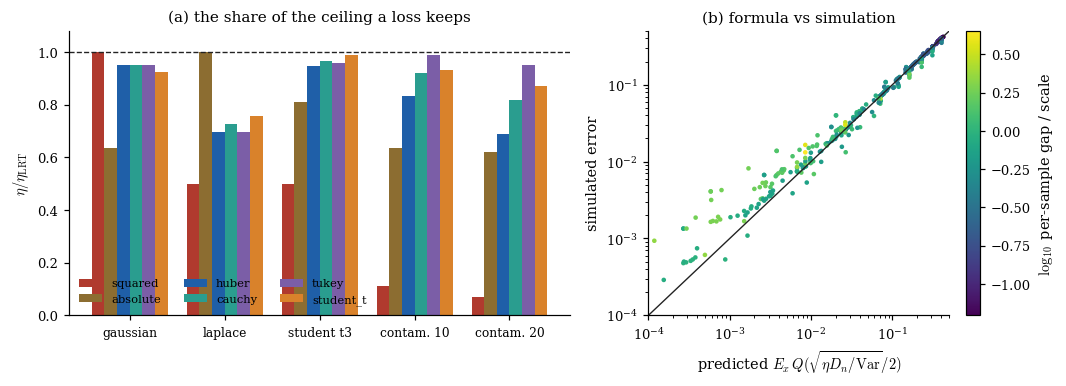

In [6]:
from analysis.figs_losses import FIGURES as LF
LF["loss_efficiency"]();

In [7]:
pd.read_csv(RES / "losses" / "v8_verdict.csv").pivot_table(
    index="loss", columns="gap_bin", values="share_within").round(2)

gap_bin,"(0.0, 0.1]","(0.1, 0.25]","(0.25, 0.5]","(0.5, inf]"
loss,,,,
absolute,1.00,0.27,0.00,0.12
cauchy,1.00,1.00,0.93,0.37
huber,1.00,1.00,0.93,0.39
lrt,1.00,0.91,0.79,0.31
squared,0.67,0.73,0.50,0.24
student_t,1.00,1.00,0.93,0.37
tukey,1.00,1.00,0.93,0.43


## 4 · The estimator under each loss, and a learned loss

The same comparison with the **estimator** instead of an oracle: every loss
in the hard loop, the soft EM with Gaussian and with Student-t noise, and
`loss="learned"`, which refits the noise model to the residuals each
iteration. Mean matched error over three pairs, two separations, three seeds.

In [8]:
S = pd.read_csv(RES / "losses" / "loss_estimator_summary.csv")
S.pivot_table(index="arm", columns="noise", values="mean_error").round(3)

noise,contaminated_10,gaussian,laplace,student_t3
arm,,,,
hard_cauchy,0.000,0.076,0.039,0.021
hard_huber,0.000,0.075,0.043,0.022
hard_learned,0.000,0.064,0.026,0.019
hard_squared,0.068,0.065,0.071,0.059
hard_student_t,0.000,0.078,0.037,0.021
hard_tukey,0.000,0.078,0.040,0.022
mechanism_kmeans,0.069,0.066,0.073,0.059
oracle_lrt,0.000,0.064,0.024,0.018
oracle_squared,0.063,0.064,0.066,0.057


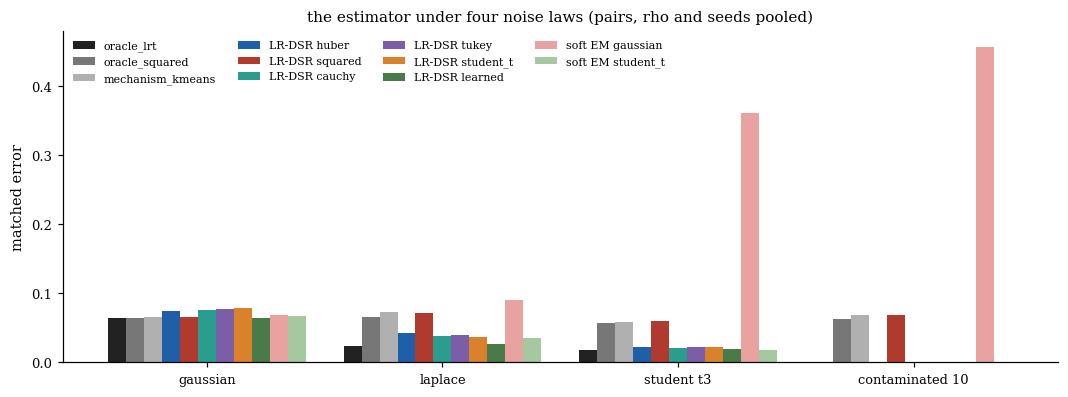

In [9]:
LF["loss_estimator"]();

Two honest readings of that table:

* the **learned** loss is within a fraction of a percent of the true-noise
  oracle under every noise — learning the loss recovers the Bayes rule;
* the default **Huber** loss still trails the squared loss a little under
  Gaussian noise. It used to trail it by ~30%: residuals were divided by the
  raw MAD (0.67 sigma), so `delta = 1.5` was really ~1 sigma, where Huber is
  only ~90% efficient. The scale is now in sigma units and `delta = 1.345`,
  chosen on the tuning seeds -- the sweep is below. And a soft EM that
  *assumes* Gaussian noise collapses under heavy tails, where its Student-t
  twin sits on the oracle.

In [10]:
# the sweep that chose the default Huber constant (tuning seeds {3, 7, 19});
# delta = 1.0 is about where the old default sat, 100 is the squared loss
H = pd.read_csv(RES / "losses" / "loss_huber_delta_summary.csv")
H.pivot_table(index="noise", columns="delta", values="matched_error").round(4)

delta,1.000,1.345,1.500,2.000,3.000,100.000
noise,,,,,,
contaminated_10,0.0007,0.0007,0.0007,0.0007,0.0011,0.0574
gaussian,0.0593,0.0489,0.0493,0.0474,0.0504,0.0493
laplace,0.0337,0.0437,0.0430,0.0493,0.0563,0.0674
student_t3,0.0207,0.0185,0.0189,0.0211,0.0281,0.0544


Learning $\nu$: the Student-t tail parameter each learner converges to.

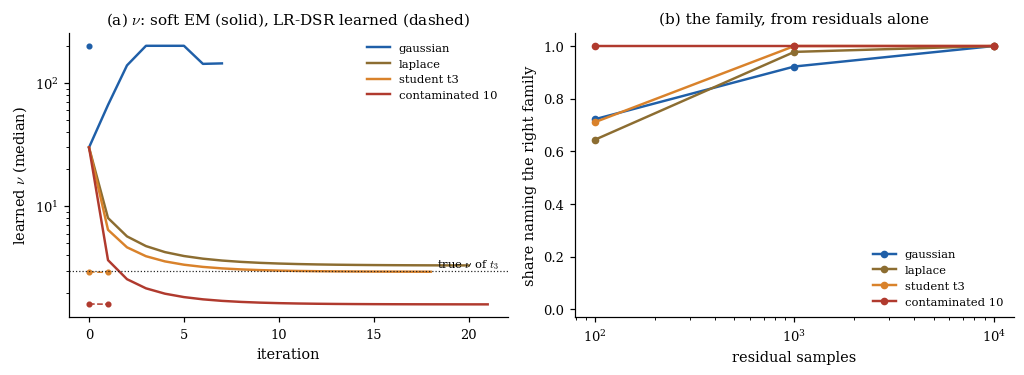

In [11]:
LF["loss_learning"]();

In [12]:
from lrdsr.core.losses import learn_loss
rng = np.random.default_rng(3)
samples = {"gaussian": rng.normal(size=5000), "laplace": rng.laplace(size=5000),
           "student_t3": rng.standard_t(3, 5000),
           "contaminated_10": np.where(rng.random(5000) < 0.1, 10, 1) * rng.normal(size=5000)}
pd.DataFrame([{"noise": k, "learned loss": (fit := learn_loss(v)).loss,
               "nu": fit.params.get("nu"), "scale": fit.scale} for k, v in samples.items()])

,noise,learned loss,nu,scale
0,gaussian,squared,NaN,1.0055
1,laplace,absolute,NaN,1.0058
2,student_t3,student_t,2.9772,0.9628
3,contaminated_10,student_t,1.5777,0.8252


## 5 · Sequential detection: the real-time ceiling

For a stream that switches law, the per-sample Kullback-Leibler divergence is
$\rho/2$. CUSUM with threshold $h$ detects the switch after
$\approx 2h/\rho$ samples (first order); Siegmund's correction for the
overshoot makes it $\approx (h' + e^{-h'} - 1)/\mathrm{KL}$ with $h'$ the
threshold plus the expected overshoot.

In [13]:
from lrdsr.theory.sequential import predicted_arl, predicted_delay
tab = pd.DataFrame([{"rho": r, "h": h,
                     "delay 2h/rho": predicted_delay(h, r, method="first_order"),
                     "delay (Siegmund)": predicted_delay(h, r, kappa=0.8),
                     "ARL >= e^h": predicted_arl(h, r, method="first_order")}
                    for r in (0.25, 1.0) for h in (3, 6, 9)])
tab.round({"delay 2h/rho": 1, "delay (Siegmund)": 1, "ARL >= e^h": 0})

,rho,h,delay 2h/rho,delay (Siegmund),ARL >= e^h
0,0.25,3,24.0,21.0,20.0
1,0.25,6,48.0,44.8,403.0
2,0.25,9,72.0,68.8,8103.0
3,1.00,3,6.0,6.6,20.0
4,1.00,6,12.0,12.6,403.0
5,1.00,9,18.0,18.6,8103.0


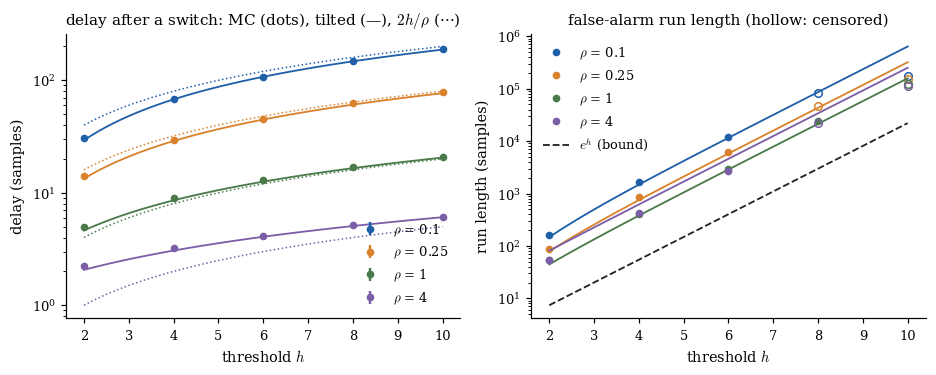

In [14]:
from analysis.figs_online import FIGURES as OF
OF["online_sequential"]();